In [1]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch

In [2]:
DELTA = 4.0 
MOT_W, MOT_H = 35.0, 42.0 
RACK_W = 8.0 
RACK_H_FULL = 70.0 
RACK_H_CASING = 69.0  # Рабочая длина рейки в корпусе

# Радиус описанной вокруг мотора окружности (для проверки зазора с D40)
R_MOT = np.hypot(MOT_W / 2.0, MOT_H / 2.0)

PENALTY_WEIGHT = 3000

In [3]:
def layout(theta): #theta - матрица весов, в нашем случае углы расстояний между колесами
    alpha, beta, gamma = theta[0], theta[1], theta[2]

    x1 = torch.tensor(0.0)
    y1 = torch.tensor(0.0) #зафиксирвоанное положение первого колеса

    x2 = x1 + 15.0 * torch.cos(alpha)
    y2 = y1 + 15.0 * torch.sin(alpha)

    x3 = x2 + 20.0 * torch.cos(beta)
    y3 = y2 + 20.0 * torch.sin(beta)

    x4 = x3 + 30.0 * torch.cos(gamma) #сказали больше комменатриев делать но тут врод ясно ды
    y4 = y3 + 30.0 * torch.sin(gamma) 

    rack_x1 = x4 + 20.0
    rack_x2 = rack_x1 + RACK_W

    rack_casing = (rack_x1, rack_x2, y4 - RACK_H_CASING / 2.0, y4 + RACK_H_CASING / 2.0)
    rack_full = (rack_x1, rack_x2, y4 - RACK_H_FULL / 2.0, y4 + RACK_H_FULL / 2.0)

    axes = ((x1, y1), (x2, y2), (x3, y3), (x4, y4))
    return axes, rack_casing, rack_full
    

In [4]:
def get_bounding_box(axes, rack_casing):
    (x1, y1), (x2, y2), (x3, y3), (x4, y4) = axes
    rx1, rx2, ry1_cas, ry2_cas = rack_casing
    #по факту дальше мы закинем все точки в массив, а в нем найдем крайние точки и там площадь бах бах 
    xs_min = torch.stack(
        [-torch.tensor(MOT_W / 2.0), x2 - 10.0, x3 - 15.0, x4 - 25.0, rx1]
    )

    xs_max = torch.stack(
        [torch.tensor(MOT_W / 2.0), x2 + 10.0, x3 + 15.0, x4 + 25.0, rx2]
    )

    ys_min = torch.stack(
        [-torch.tensor(MOT_H / 2.0), y2 - 10.0, y3 - 15.0, y4 - 25.0, ry1_cas]
    )

    ys_max = torch.stack(
        [torch.tensor(MOT_H / 2.0), y2 + 10.0, y3 + 15.0, y4 + 25.0, ry2_cas]
    )
    width = torch.max(xs_max) - torch.min(xs_min)
    height = torch.max(ys_max) - torch.min(ys_min) 

    return width, height

In [5]:
def check_collisions(axes, rack_full):
    (x1, y1), (x2, y2), (x3, y3), (x4, y4) = axes
    rx1, rx2, ry1_full, ry2_full = rack_full

    d13 = torch.hypot(x3 - x1, y3 - y1)
    loss_13 = torch.relu(24.0 - d13) ** 2 #вы поняли да если коллизия то релушечка родная даст ошибку хорошую

    d24 = torch.hypot(x4 - x2, y4 - y2)
    loss_24 = torch.relu(39.0 - d24) ** 2

    dx = torch.maximum(
        -torch.tensor(MOT_W / 2.0) - rx2, rx1 - torch.tensor(MOT_W / 2.0)
    )
    dy = torch.maximum(
        -torch.tensor(MOT_H / 2.0) - ry2_full,
        ry1_full - torch.tensor(MOT_H / 2.0),
    )

    # короче параллельные прямоугольники не персекаются если их разделяет прямая по какой либо из осей
    gap = torch.maximum(dx, dy)
    loss_rack_mot = torch.relu(DELTA - gap) ** 2

    d14 = torch.hypot(x4 - x1, y4 - y1)
    loss_mot_c4 = torch.relu((20.0 + R_MOT + DELTA) - d14) ** 2

    # Суммарный штраф
    total_penalty = loss_13 + loss_24 + loss_rack_mot + loss_mot_c4
    return total_penalty

In [6]:
def compute_loss(theta):
    axes, rack_casing, rack_full = layout(theta)
    width, height = get_bounding_box(axes, rack_casing)
    raw_penalty = check_collisions(axes, rack_full)
    
    area = width * height

    total_loss = area + PENALTY_WEIGHT * raw_penalty

    return total_loss, area, raw_penalty, (width, height)

In [27]:
# theta = torch.nn.Parameter(torch.rand(3) * 2 * np.pi) 
## так как у нас релу то He не пойдет мы вот да вот эту тему 
# theta_tensor = torch.empty(1, 3)
# torch.nn.init.kaiming_uniform_(theta_tensor, a=0, mode='fan_in', nonlinearity='leaky_relu')
# theta = torch.nn.Parameter(theta_tensor.squeeze(0))
theta = torch.nn.Parameter(torch.tensor([1.8326, 3.3161, 3.5081]))
optimizer = torch.optim.Adam([theta], lr=0.03)

print("Запуск оптимизации компоновки...")

for epoch in range(10001):
    optimizer.zero_grad()

    loss, area, penalty, (w, h) = compute_loss(theta)

    loss.backward()

    optimizer.step()
    # scheduler.step()

    if epoch % 200 == 0:
        print(
            f"{epoch:3d} Loss: {loss.item():.1f} Площадь: {area.item():.1f} Штраф: {penalty.item():.4f}"
        )

with torch.no_grad():
    _, final_area, final_pen, (final_w, final_h) = compute_loss(theta)
    final_deg = (theta.numpy() * 180 / np.pi) % 360

print(
    f"Оптимальные углы: α={final_deg[0]:.1f}°, β={final_deg[1]:.1f}°, γ={final_deg[2]:.1f}°"
)
print(f"Габариты: {final_w.item():.2f} × {final_h.item():.2f} мм")
print(f"Площадь корпуса: {final_area.item():.1f} мм²")
print(f"Коллизии устранены: {final_pen.item() < 1e-3}")

Запуск оптимизации компоновки...
  0 Loss: 4774.9 Площадь: 4774.9 Штраф: 0.0000
200 Loss: 4689.5 Площадь: 4689.5 Штраф: 0.0000
400 Loss: 4695.4 Площадь: 4695.4 Штраф: 0.0000
600 Loss: 4707.4 Площадь: 4707.4 Штраф: 0.0000
800 Loss: 4684.0 Площадь: 4683.4 Штраф: 0.0002
1000 Loss: 4696.1 Площадь: 4696.1 Штраф: 0.0000
1200 Loss: 4710.5 Площадь: 4710.5 Штраф: 0.0000
1400 Loss: 4715.9 Площадь: 4715.9 Штраф: 0.0000
1600 Loss: 4687.6 Площадь: 4687.6 Штраф: 0.0000
1800 Loss: 4738.9 Площадь: 4738.9 Штраф: 0.0000
2000 Loss: 4687.2 Площадь: 4687.2 Штраф: 0.0000
2200 Loss: 4694.0 Площадь: 4694.0 Штраф: 0.0000
2400 Loss: 4698.5 Площадь: 4698.5 Штраф: 0.0000
2600 Loss: 4725.6 Площадь: 4725.6 Штраф: 0.0000
2800 Loss: 4693.3 Площадь: 4693.3 Штраф: 0.0000
3000 Loss: 4704.7 Площадь: 4704.7 Штраф: 0.0000
3200 Loss: 4714.6 Площадь: 4714.6 Штраф: 0.0000
3400 Loss: 4692.6 Площадь: 4692.6 Штраф: 0.0000
3600 Loss: 4717.6 Площадь: 4717.6 Штраф: 0.0000
3800 Loss: 4696.2 Площадь: 4696.2 Штраф: 0.0000
4000 Loss: 4

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import torch


def plot_gearbox(theta):
    with torch.no_grad():
        axes, rack_cas, rack_full = layout(theta)
        w, h = get_bounding_box(axes, rack_cas)
        (x1, y1), (x2, y2), (x3, y3), (x4, y4) = [(p[0].item(), p[1].item()) for p in axes]
        rx1, rx2, ry1, ry2 = [v.item() for v in rack_cas]
        bx = min(-MOT_W / 2, x2 - 10, x3 - 15, x4 - 25, rx1)
        by = min(-MOT_H / 2, y2 - 10, y3 - 15, y4 - 25, ry1)

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.add_patch(
        plt.Rectangle(
            (bx, by),
            w.item(),
            h.item(),
            fill=False,
            ls="--",
            lw=2,
            color="black",
            label=f"Корпус: {w.item():.1f}×{h.item():.1f} мм",
        )
    )

    ax.add_patch(
        plt.Rectangle(
            (-MOT_W / 2, -MOT_H / 2),
            MOT_W,
            MOT_H,
            color="orange",
            alpha=0.3,
            label="Мотор",
        )
    )

    ax.add_patch(
        plt.Rectangle(
            (rx1, ry1), RACK_W, RACK_H_CASING, color="purple", alpha=0.5, label="Рейка"
        )
    )

    circles = [
        (x1, y1, 5),
        (x2, y2, 10),
        (x2, y2, 5),
        (x3, y3, 15),
        (x3, y3, 5),
        (x4, y4, 25),
        (x4, y4, 20),
    ]
    for cx, cy, r in circles:
        ax.add_patch(plt.Circle((cx, cy), r, fill=False, lw=1.2, color="blue"))
    ax.plot([x1, x2, x3, x4], [y1, y2, y3, y4], "ro-", lw=1.5, label="Оси O1-O4")

    ax.set_aspect("equal")
    ax.grid(True, ls=":")
    ax.legend(loc="upper left")
    plt.title("Компоновка редуктора")
    plt.show()

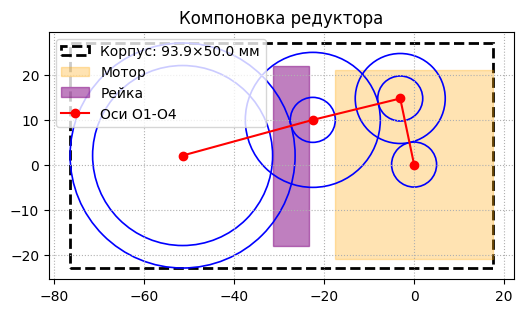

In [29]:
plot_gearbox(theta)

Наверное, стоит проверить, можем ли мы двинуться к большему минимуму.